In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

df = sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [5]:
df.to_csv("titanic.csv", index=False)

print("Offline fallback saved as titanic.csv")

Offline fallback saved as titanic.csv


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.shape

(891, 15)

In [10]:
df.columns.to_list()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [13]:
missing_count = df.isnull().sum()
missing_count



survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [14]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [15]:
missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

missing_table = missing_table[
    missing_table["Missing Count"] > 0
]

print(missing_table)

             Missing Count  Missing Percentage
age                    177           19.865320
embarked                 2            0.224467
deck                   688           77.216611
embark_town              2            0.224467


In [16]:
for column in missing_table.index:
    percentage = missing_percent[column]
    print(f"{column}: {percentage:.2f}%")

age: 19.87%
embarked: 0.22%
deck: 77.22%
embark_town: 0.22%


In [ ]:
df = df.drop(columns=["deck"])

drop_rows_columns = ["embarked", "embark_town", "fare"]
df = df.dropna(subset=drop_rows_columns)

df["age"] = df["age"].fillna(df["age"].median())
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


### Missing Value Handling
- `age`: 19.87% missing → 5–30% band → **imputed** with the median
- `embarked` / `embark_town`: 0.22% missing each → <5% → **rows dropped**
- `deck`: 77.22% missing → well above 30% → **column dropped entirely**

In [18]:
df.shape

(889, 14)

In [20]:
df.to_csv("titanic.csv", index=False)

print("Cleaned Titanic dataset saved.")

Cleaned Titanic dataset saved.


In [22]:
import os

os.makedirs("charts", exist_ok=True)
import matplotlib.pyplot as plt

## 1. Age Distribution

- This histogram shows the distribution of passenger ages in the Titanic dataset.
- The x-axis represents **Age**.
- The y-axis represents the **Frequency** of passengers.
- The distribution helps us understand how passenger ages are spread across the dataset.
- This visualization can also help identify the approximate concentration and spread of passenger ages.

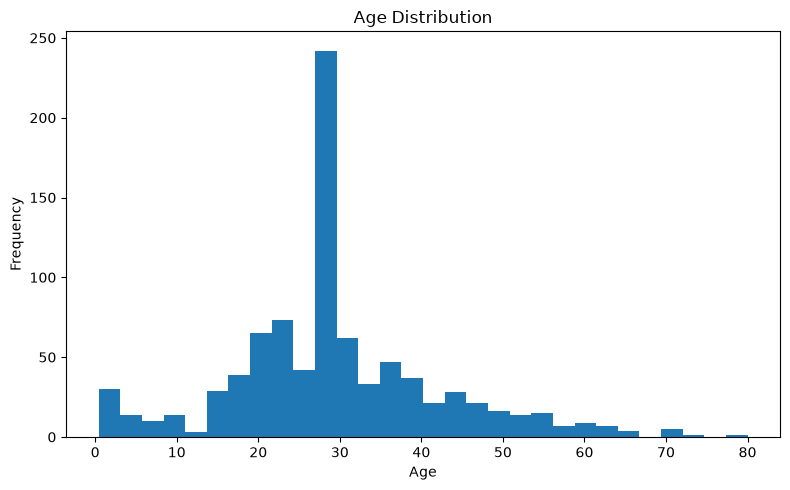

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(df["age"], bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("charts/age_histogram.png")
plt.show()

## 2. Age Box Plot

- This box plot summarizes the distribution of passenger ages.
- It shows the **median, quartiles, overall spread, and potential outliers**.
- The visualization helps identify unusually high or low age values.
- Box plots are useful for understanding the variability of a numerical feature.

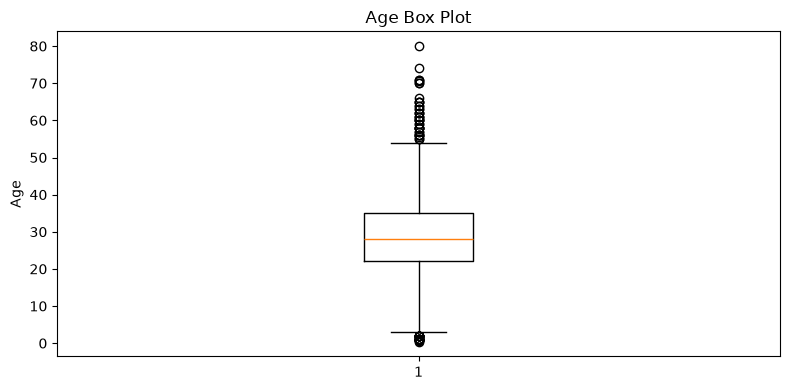

In [24]:
plt.figure(figsize=(8, 4))

plt.boxplot(df["age"])

plt.title("Age Box Plot")
plt.ylabel("Age")

plt.tight_layout()
plt.savefig("charts/age_boxplot.png")
plt.show()

## 3. Fare Distribution

- This histogram shows the distribution of passenger fares.
- The x-axis represents **Fare**.
- The y-axis represents the **Frequency** of passengers.
- The visualization helps us understand how fare values are distributed.
- It can also help identify whether most passengers paid lower or higher fares and whether the distribution has a long tail.

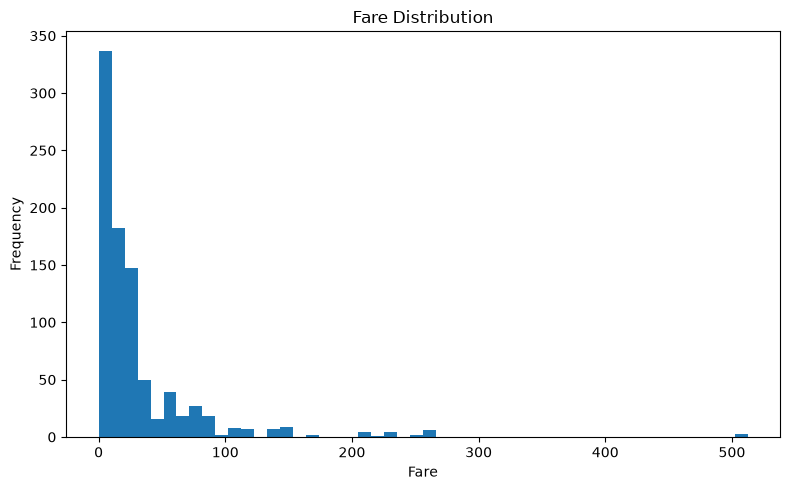

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(df["fare"], bins=50)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("charts/fare_histogram.png")
plt.show()

## 4. Fare Box Plot

- This box plot summarizes the distribution of passenger fares.
- It shows the **median, quartiles, spread, and potential outliers**.
- The plot helps identify unusually high or low fare values.
- This is useful because extreme fare values can affect statistical analysis and machine learning models.

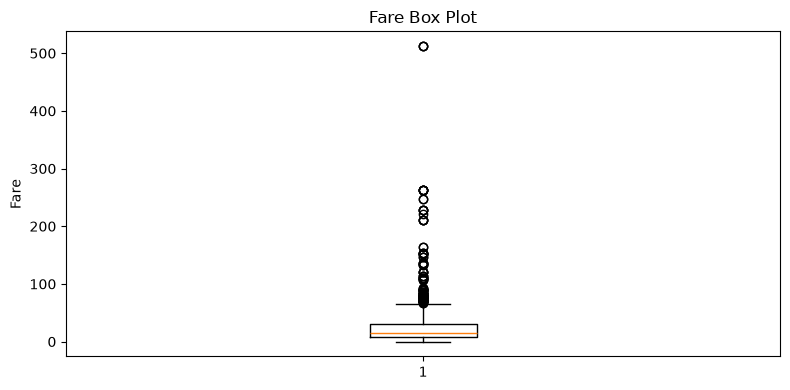

In [27]:
plt.figure(figsize=(8, 4))

plt.boxplot(df["fare"])

plt.title("Fare Box Plot")
plt.ylabel("Fare")

plt.tight_layout()
plt.savefig("charts/fare_boxplot.png")
plt.show()

In [35]:
    Q1 = df["age"].quantile(0.25)
    Q3 = df["age"].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df["age"] < lower_limit) |
        (df["age"] > upper_limit)
    ]
    print("AGE")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)
    print("Number of outliers:", len(outliers))
    
    

AGE
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower limit: 2.5
Upper limit: 54.5
Number of outliers: 65


In [ ]:
    Q1 = df["fare"].quantile(0.25)
    Q3 = df["fare"].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df["fare"] < lower_limit) |
        (df["fare"] > upper_limit)
    ]
    print("AGE")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)
    print("Number of outliers:", len(outliers))

AGE
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower limit: -26.7605
Upper limit: 65.6563
Number of outliers: 114


    ### Outlier Counts (IQR method)
    - `age`: 65 outliers (outside [2.5, 54.5])
    - `fare`: 114 outliers (outside [-26.76, 65.66])

In [37]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05


In [ ]:

if fare_mean > fare_median > fare_mode:
    print("Fare distribution is right-skewed.")
elif fare_mean < fare_median < fare_mode:
    print("Fare distribution is left-skewed.")
else:
    print("Fare distribution is approximately symmetric.")

Fare distribution is right-skewed.


### Fare Skewness
Mean (32.10) > Median (14.45) > Mode (8.05) → `fare` is **right-skewed** — a small number of high-fare passengers pull the mean above the typical fare.

In [39]:
male = df[df["sex"] == "male"]

female = df[df["sex"] == "female"]

male_survival_rate = male["survived"].mean()
female_survival_rate = female["survived"].mean()

print("Male survival rate:", male_survival_rate)
print("Female survival rate:", female_survival_rate)

Male survival rate: 0.18890814558058924
Female survival rate: 0.7403846153846154


In [41]:
female_first_class = df[
    (df["sex"] == "female") &
    (df["pclass"] == 1)
]

female_first_class

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,Southampton,yes,True
31,1,1,female,28.0,1,0,146.5208,C,First,woman,False,Cherbourg,yes,False
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,1,1,female,45.0,1,1,164.8667,S,First,woman,False,Southampton,yes,False
862,1,1,female,48.0,0,0,25.9292,S,First,woman,False,Southampton,yes,True
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,Southampton,yes,False
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,Cherbourg,yes,False


In [42]:
pclass_survival = df.groupby("pclass")["survived"].mean()

print(pclass_survival)

pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64


In [ ]:
sex_pclass_survival = (
    df.groupby(["sex", "pclass"])["survived"]
    .mean()
)

print(sex_pclass_survival)

sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


### Bivariate Survival Rates
- By sex: male 18.9%, female 74.0%
- By class: 1st 62.6%, 2nd 47.3%, 3rd 24.2%
- By sex+class: female 1st 96.7%, female 2nd 92.1%, female 3rd 50.0%, male 1st 36.9%, male 2nd 15.7%, male 3rd 13.5%

## 5. Survival Rate by Sex

- This bar chart compares the survival rate between male and female passengers.
- The x-axis represents **Sex**.
- The y-axis represents the **Survival Rate**.
- The chart helps explore the relationship between passenger sex and survival.
- Survival rate is calculated as the mean of the `survived` variable for each sex.

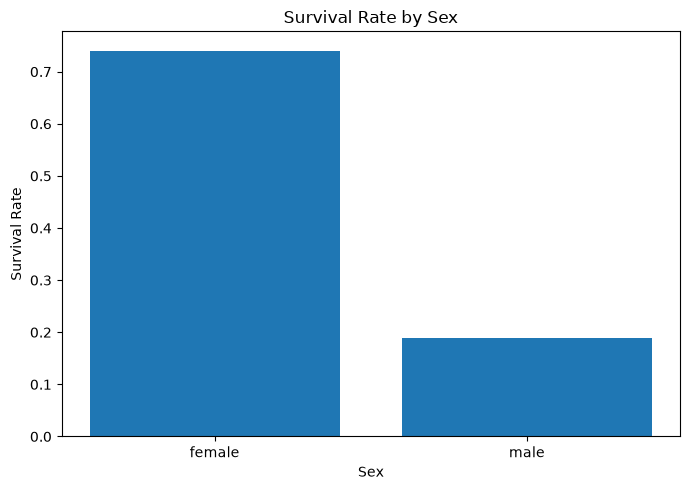

In [44]:
survival_sex = df.groupby("sex")["survived"].mean()

plt.figure(figsize=(7, 5))

plt.bar(
    survival_sex.index,
    survival_sex.values
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("charts/survival_by_sex.png")
plt.show()

## 6. Survival Rate by Passenger Class

- This bar chart compares survival rates across the different passenger classes.
- The x-axis represents **Passenger Class**.
- The y-axis represents the **Survival Rate**.
- The visualization helps examine the relationship between passenger class and survival.
- Survival rate is calculated by grouping passengers according to `pclass`.

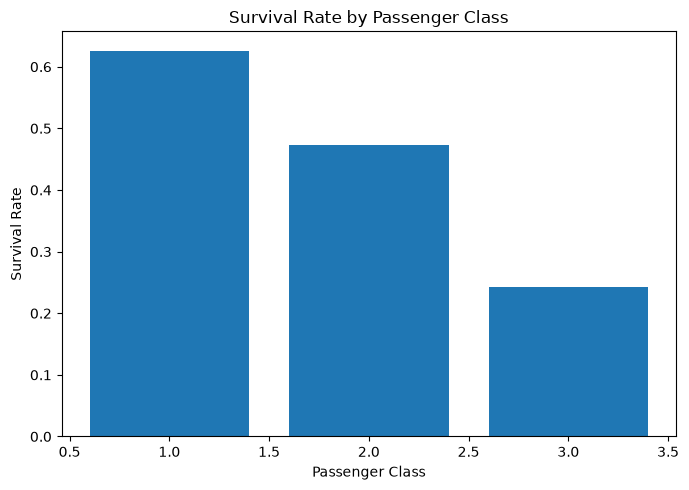

In [45]:
survival_class = df.groupby("pclass")["survived"].mean()

plt.figure(figsize=(7, 5))

plt.bar(
    survival_class.index,
    survival_class.values
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("charts/survival_by_class.png")
plt.show()

## 7. Survival Rate by Sex and Passenger Class

- This bar chart examines survival rates using both **sex** and **passenger class**.
- Passengers are grouped by `pclass` and `sex`.
- The y-axis represents the **Survival Rate**.
- This visualization allows us to examine how survival rates vary across combinations of passenger class and sex.
- It provides a more detailed view than analyzing sex or passenger class separately.

pclass  sex   
1       female    0.967391
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: survived, dtype: float64


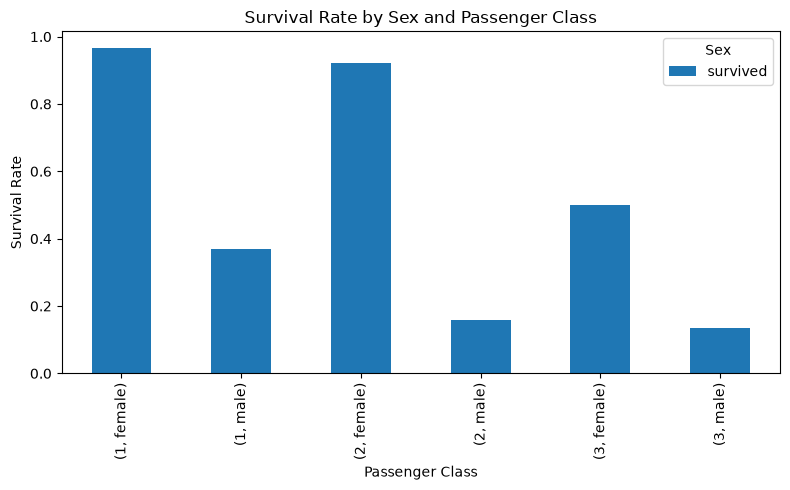

In [46]:
survival = (
    df.groupby(["pclass", "sex"])["survived"]
      .mean()
)

print(survival)

survival.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.legend(title="Sex")

plt.tight_layout()
plt.savefig("charts/survival_sex_class.png")
plt.show()

In [47]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


## 8. Correlation Heatmap

- This heatmap displays the correlation between selected numerical variables in the Titanic dataset.
- The correlation values range from **-1 to +1**.
- A positive value indicates that two variables tend to increase together.
- A negative value indicates that one variable tends to increase as the other decreases.
- A value close to zero indicates a weaker linear relationship.
- The heatmap helps identify relationships between features and the target variable `survived`.

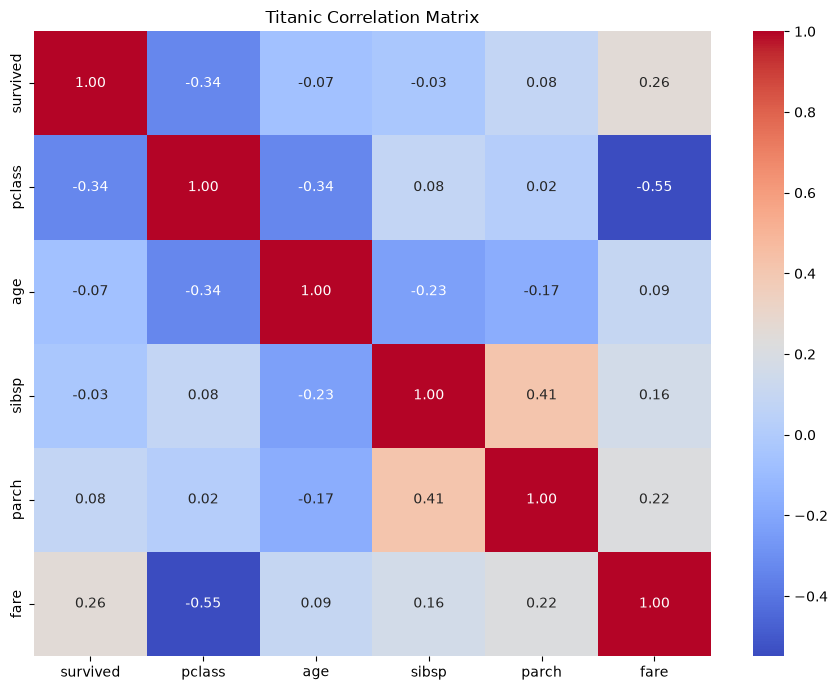

In [48]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Titanic Correlation Matrix")

plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png")
plt.show()

In [52]:
import numpy as np

# Keep only the upper triangle and remove diagonal
upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Convert to pairs
corr_pairs = upper.stack()

# Get 2 strongest correlations by absolute value
top_pairs = corr_pairs.loc[
    corr_pairs.abs().nlargest(2).index
]

print("Two strongest correlations:")

print(top_pairs)

Two strongest correlations:
pclass  fare    -0.548193
sibsp   parch    0.414542
dtype: float64


## 9. Age vs Fare by Survival

- This scatter plot shows the relationship between **Age** and **Fare**.
- The x-axis represents **Age**.
- The y-axis represents **Fare**.
- The points are differentiated using the `survived` variable.
- This visualization helps explore whether there are noticeable patterns between age, fare, and survival.
- Scatter plots are useful for examining relationships and distributions between two numerical variables.

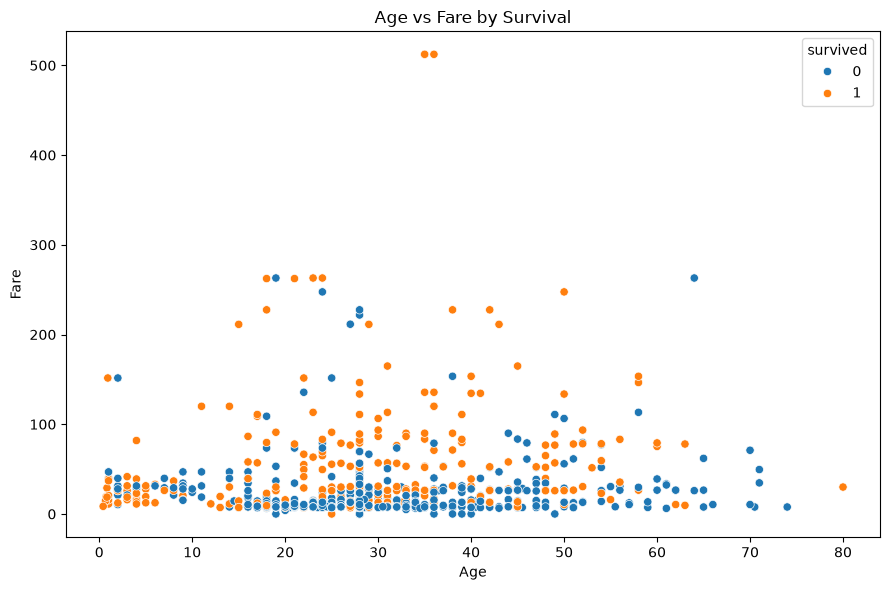

In [53]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.tight_layout()
plt.savefig("charts/age_fare_survival.png")
plt.show()

In [ ]:
scaler = StandardScaler()


df_eda_scaled = df.copy()

df_eda_scaled[["age", "fare"]] = scaler.fit_transform(
    df_eda_scaled[["age", "fare"]]
)

print("Before scaling:")
print(df[["age", "fare"]].agg(["mean", "std"]))

print("\nAfter scaling:")
print(
    df_eda_scaled[["age", "fare"]]
    .agg(["mean", "std"])
)

Before scaling:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After scaling:
               age          fare
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


### Standardization Check
Before: age mean=29.32/std=12.98, fare mean=32.10/std=49.70
After: age mean≈0/std≈1, fare mean≈0/std≈1 — confirms standardization worked correctly.